In [213]:
import numpy as np
import matplotlib.pyplot as plt
import math
from random import random

# Nernst Equation

In [214]:
def e_ion(
    z: float,  # charge of the ion
    mM_inside: float,  # ion concentration inside the cell
    mM_outside: float,  # ion concentration outside the cell
):
    # 61 calculated using values such as the universal gas constant and temperature of mammalian cells
    return (61 / z) * math.log(mM_outside / mM_inside, 10)


# Ion	Inside concentration (mM)	Outside concentration (mM)	Equilibrium Potential
# Sodium	15	145	+60 mV
# Potassium	125	5	-85 mV
# Chloride	13	150	-65 mV
E_NA = e_ion(1, 15, 145)
E_K = e_ion(1, 125, 5)
E_CL = e_ion(-1, 13, 150)

print(f"e_na: {E_NA:.0f}")
print(f"e_k: {E_K:.0f}")
print(f"e_cl: {E_CL:.0f}")

e_na: 60
e_k: -85
e_cl: -65


In [215]:
# The resting potential of the neuron's membrane is a weighted average of the Nernst potentials,
# w/ weights = macroscopic conductance (g) of the channels in the membrane
# G_NA =
# G_K =
# G_CL =
# E_NEURON = (gNa * E_NA + gK * E_K + gCl * E_CL) / (gNa + gK + gCl)

In [216]:
# V = current V of the neuron
# I_NA = gNa * (V - E_NA)
# I_K = gK * (V - E_K)
# I_Cl = gCl * (V - E_CL)


def i_ion(
    g: float,  # conductance of the ion
    E: float,  # equilibrium potential of the ion
    V: float,  # membrane potential
):
    return g * (E - V)


# a = G_K + G_NA + G_CL # sum of ionic conducatances
# b = E_K + E_NA + E_CL # sum of nernst potentials
# dv_dt = ((- a * V) + b) / C

# HH Equation

In [217]:
class Gate:
    """The Gate object manages a channel's kinetics and open state"""
    alpha, beta, state = 0, 0, 0

    def update(self, deltaTms:float):
        alphaState = self.alpha * (1 - self.state)
        betaState = self.beta * self.state
        self.state += deltaTms * (alphaState - betaState)

    def set_infinite_state(self):
        self.state = self.alpha / (self.alpha + self.beta)

class HHModel:
    """The HHModel tracks conductances of 3 channels to calculate Vm"""

    ENa, EK, EKleak = 115, -12, 10.6
    gNa, gK, gKleak = 120, 36, 0.3
    m, n, h = Gate(), Gate(), Gate()
    Cm = 1

    def __init__(self, startingVoltage=0):
        self.Vm = startingVoltage
        self.update_gate_time_constants(self.Vm)
        self.m.set_infinite_state()
        self.n.set_infinite_state()
        self.h.set_infinite_state()

    def update_gate_time_constants(self, Vm):
        """Update gate time constants based on the given Vm"""
        self.n.alpha = 0.01 * ((10 - Vm) / (np.exp((10 - Vm) / 10) - 1))
        self.n.beta = 0.125 * np.exp(-Vm / 80)
        self.m.alpha = 0.1 * ((25 - Vm) / (np.exp((25 - Vm) / 10) - 1))
        self.m.beta = 4 * np.exp(-Vm / 18)
        self.h.alpha = 0.07 * np.exp(-Vm / 20)
        self.h.beta = 1 / (np.exp((30 - Vm) / 10) + 1)

    def get_membrane_voltage_and_ionic_currents(self, t_delta_ms: float, stimulus_current=0):
        """calculate channel currents using the latest gate time constants"""
        INa = np.power(self.m.state, 3) * self.gNa * self.h.state * (self.Vm - self.ENa)
        IK = np.power(self.n.state, 4) * self.gK * (self.Vm - self.EK)
        IKleak = self.gKleak * (self.Vm - self.EKleak)
        Isum = stimulus_current - INa - IK - IKleak
        Vm = self.Vm + t_delta_ms * Isum / self.Cm
        return (Vm, INa, IK, IKleak)

    def step(self, t_delta_ms: float, stimulus_current=0):
        self.update_gate_time_constants(self.Vm)
        self.Vm, INa, Ik, IKleak = self.get_membrane_voltage_and_ionic_currents(t_delta_ms, stimulus_current)
        """calculate new channel open states using latest Vm"""
        self.n.update(t_delta_ms)
        self.m.update(t_delta_ms)
        self.h.update(t_delta_ms)
        return self.Vm, INa, Ik, IKleak

    def test(self):
        return (self.gNa * self.ENa + self.gK * self.EK + self.gKleak * self.EKleak) / (self.gNa + self.gK + self.gKleak)

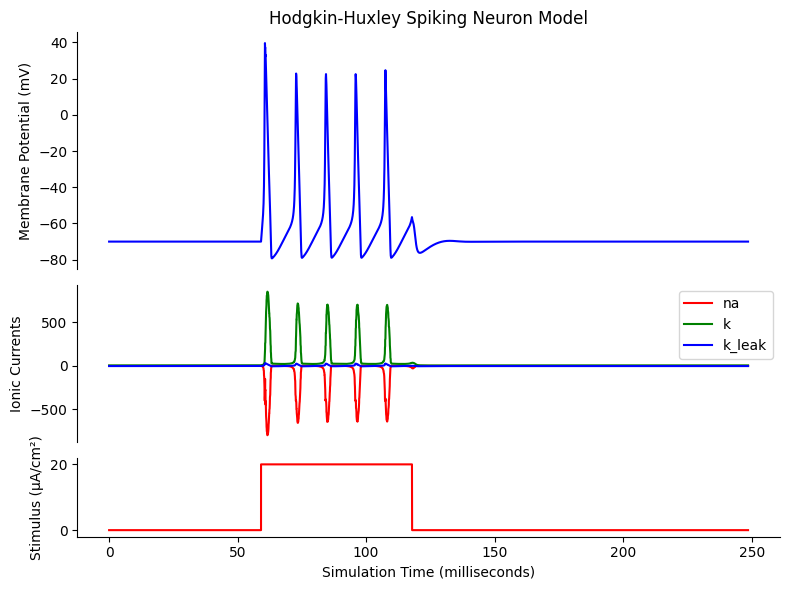

In [218]:
hh = HHModel(0)
n_steps = 5000
voltages = np.empty(n_steps)
times = np.empty(n_steps)
stim = np.zeros(n_steps)
# stim[:] = 20
# stim[0:1200] = 20  # create a square pulse
stim[1200:2400] = 20  # create a square pulse

i_na = np.empty(n_steps)
i_k = np.empty(n_steps)
i_k_leak = np.empty(n_steps)

for i in range(n_steps):
    prev = 0 if i == 0 else times[i - 1]
    t_delta_ms = 0.1 * random()
    times[i] = prev + t_delta_ms
    # i_na[i], i_k[i] = hh.get_ionic_currents()
    voltages[i], i_na[i], i_k[i], i_k_leak[i] = hh.step(t_delta_ms=t_delta_ms, stimulus_current=stim[i])
    # note: you could also plot hh's n, m, and k (channel open states)

f, (ax1, ax2, ax3) = plt.subplots(
    3, 1, sharex=True, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 2, 1]}
)

ax1.plot(times, voltages - 70, "b")
ax1.set_ylabel("Membrane Potential (mV)")
ax1.set_title("Hodgkin-Huxley Spiking Neuron Model")  # , fontSize=16)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.tick_params(bottom=False)

ax2.plot(times, i_na, "r", label="na")
ax2.plot(times, i_k, "g", label="k")
ax2.plot(times, i_k_leak, "b", label="k_leak")
ax2.legend()
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.set_ylabel("Ionic Currents")
ax2.tick_params(bottom=False)

ax3.plot(times, stim, "r")
ax3.set_ylabel("Stimulus (µA/cm²)")
ax3.set_xlabel("Simulation Time (milliseconds)")
ax3.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)


plt.margins(0, 0.1)
plt.tight_layout()
# plt.savefig("dev/concept4.png")
plt.show()

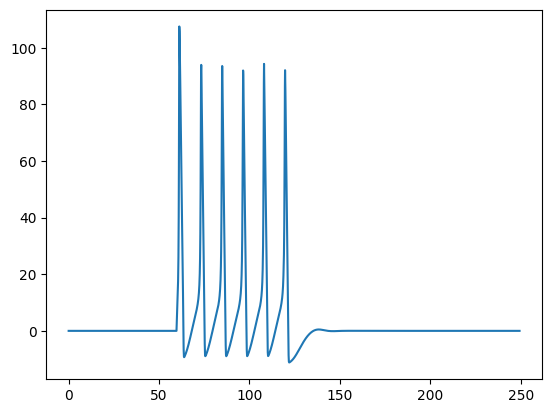

In [219]:
import json
with open("test.json", "r") as f:
    data = json.load(f)
    
    plt.figure()

    plt.plot(data["times"], data["voltages"])